### Task 2

In [ ]:
!mkdir -p /content/CSE425_project
!mkdir -p /content/CSE425_project/data

print("Project folder created at: /content/CSE425_project")

Project folder created at: /content/CSE425_project


In [ ]:
import os
PROJECT_ROOT = "/content/CSE425_project"
os.chdir(PROJECT_ROOT)
print("Current directory:", os.getcwd())

Current directory: /content/CSE425_project


In [ ]:
!pip install -q torch torchvision torchaudio
!pip install -q transformers datasets
!pip install -q librosa soundfile
!pip install -q scikit-learn pandas numpy matplotlib seaborn
!pip install -q tqdm jupyter
!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-2.0.0+cu118.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-2.0.0+cu118.html
!pip install -q torch-geometric

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.3/915.3 kB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 91.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.1 MB/s eta 0:00:00


In [ ]:
# Create project file structure
PROJECT_ROOT = '/content/CSE425_project'

AUDIO_DIR = f'{PROJECT_ROOT}/data/raw/musiccaps/audio'
CSV_PATH = f'{PROJECT_ROOT}/data/raw/musiccaps/musiccaps-public.csv'

directories = {

    'data_processed': f'{PROJECT_ROOT}/data/processed',
    'data_processed_graphs': f'{PROJECT_ROOT}/data/processed/graphs',
    'data_processed_melspec': f'{PROJECT_ROOT}/data/processed/mel-spec',
    'data_processed_bert': f'{PROJECT_ROOT}/data/processed/bert_caches',
    'data_splits': f'{PROJECT_ROOT}/data/splits',
    'results': f'{PROJECT_ROOT}/results',
    'results_plots': f'{PROJECT_ROOT}/results/plots',
    'results_metrics': f'{PROJECT_ROOT}/results/metrics',
    'results_retrieval': f'{PROJECT_ROOT}/results/retrieval_examples',
    'notebooks': f'{PROJECT_ROOT}/notebooks',
    'src': f'{PROJECT_ROOT}/src',
    'report': f'{PROJECT_ROOT}/report',
}

for name, path in directories.items():
    os.makedirs(path, exist_ok=True)
    print(f"Created: {path}")

Created: /content/CSE425_project/data/processed
Created: /content/CSE425_project/data/processed/graphs
Created: /content/CSE425_project/data/processed/mel-spec
Created: /content/CSE425_project/data/processed/bert_caches
Created: /content/CSE425_project/data/splits
Created: /content/CSE425_project/results
Created: /content/CSE425_project/results/plots
Created: /content/CSE425_project/results/metrics
Created: /content/CSE425_project/results/retrieval_examples
Created: /content/CSE425_project/notebooks
Created: /content/CSE425_project/src
Created: /content/CSE425_project/report


In [ ]:
# Import Libraries
import os
import copy
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import librosa
import librosa.display
from torch_geometric.data import Data, DataLoader, Dataset
from torch_geometric.nn import SAGEConv, global_mean_pool, GATConv, GCNConv
from torch.utils.data import DataLoader as TorchDataLoader
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load GTZAN Dataset
print("\nLoading GTZAN dataset from Hugging Face...")
from datasets import load_dataset

gtzan = load_dataset("ParitKansal/marsyas-gtzan", split="train")
print(f"Dataset Loaded Successfully!")


Loading GTZAN dataset from Hugging Face...


Dataset Loaded Successfully!


In [ ]:
# Dataset Information

In [ ]:
print(f"\nTotal number of samples: {len(gtzan)}")


Total number of samples: 999


In [ ]:
from collections import Counter
genres = [item["genre"] for item in gtzan]
genre_counts = Counter(genres)

print(f"\nNumber of unique genres: {len(genre_counts)}")


Number of unique genres: 10


In [ ]:
print("\nGenre distribution:")

genre_df = pd.DataFrame({
    'Genre': list(genre_counts.keys()),
    'Count': list(genre_counts.values())
}).sort_values('Count', ascending=False)

print(genre_df.to_string(index=False))


Genre distribution:
 Genre  Count
     0    100
     1    100
     2    100
     3    100
     4    100
     6    100
     8    100
     7    100
     9    100
     5     99


In [ ]:
durations = []
sample_rates = []

for i, item in enumerate(gtzan):
    audio = item["audio"]["array"]
    sr = item["audio"]["sampling_rate"]
    duration = len(audio) / sr
    durations.append(duration)
    sample_rates.append(sr)

    if i >= 100:
        break

print(f"Audio duration (first 100 samples):")
print(f"   Min: {min(durations):.2f} seconds")
print(f"   Max: {max(durations):.2f} seconds")
print(f"   Mean: {np.mean(durations):.2f} seconds")

Audio duration (first 100 samples):
   Min: 30.01 seconds
   Max: 30.01 seconds
   Mean: 30.01 seconds


In [ ]:
for i in range(min(5, len(gtzan))):
    item = gtzan[i]
    audio = item["audio"]["array"]
    sr = item["audio"]["sampling_rate"]
    duration = len(audio) / sr

    print(f"\n--- Sample {i} ---")
    print(f"  Genre: {item['genre']}")
    print(f"  Duration: {duration:.2f} seconds")
    print(f"  Sample Rate: {sr} Hz")


--- Sample 0 ---
  Genre: 0
  Duration: 30.01 seconds
  Sample Rate: 22050 Hz

--- Sample 1 ---
  Genre: 0
  Duration: 30.01 seconds
  Sample Rate: 22050 Hz

--- Sample 2 ---
  Genre: 0
  Duration: 30.01 seconds
  Sample Rate: 22050 Hz

--- Sample 3 ---
  Genre: 0
  Duration: 30.01 seconds
  Sample Rate: 22050 Hz

--- Sample 4 ---
  Genre: 0
  Duration: 30.01 seconds
  Sample Rate: 22050 Hz


In [ ]:
plots_dir = '/content/CSE425_project/results/plots'
os.makedirs(plots_dir, exist_ok=True)

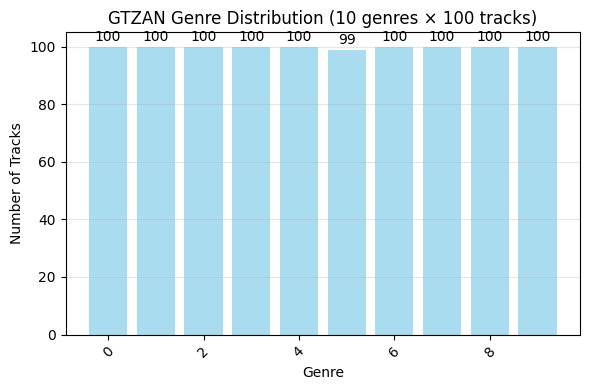

Genre distribution saved


In [ ]:
# Genre Distribution Bar Chart
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(genre_df['Genre'], genre_df['Count'], color='skyblue', alpha=0.7)
ax.set_xlabel('Genre')
ax.set_ylabel('Number of Tracks')
ax.set_title('GTZAN Genre Distribution (10 genres × 100 tracks)')
ax.grid(True, alpha=0.3, axis='y')

for bar, count in zip(bars, genre_df['Count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{count}', ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{plots_dir}/gtzan_genre_distribution.png', dpi=150)
plt.show()
print("Genre distribution saved")

In [ ]:
# Dataset Details
audio_paths = []
genres = []
audio_arrays = []
sample_rates = []

for item in gtzan:
    audio = item["audio"]

    audio_arrays.append(audio.get_all_samples().data.numpy())
    sample_rates.append(audio.metadata.sample_rate)
    genres.append(item["genre"])

GTZAN_GENRE_NAMES = ['blues', 'classical', 'country', 'disco', 'hiphop',
                      'jazz', 'metal', 'pop', 'reggae', 'rock']
genres = [GTZAN_GENRE_NAMES[item["genre"]] for item in gtzan]

print(f"Genres: {set(genres)}")

Genres: {'classical', 'jazz', 'rock', 'pop', 'metal', 'blues', 'reggae', 'hiphop', 'disco', 'country'}


In [ ]:
# Define Variables
SAMPLE_RATE = 22050
DURATION = 30  # GTZAN tracks are 30 seconds
SEGMENT_LENGTH = 3.0  # 3-second segments
SEGMENT_HOP = 1.5
N_MFCC = 13
N_CHROMA = 12
USE_CHROMA = True
SIMILARITY_THRESHOLD = 0.7

# GNN parameters
GNN_HIDDEN = 64
GNN_LAYERS = 3
DROPOUT = 0.3
LEARNING_RATE = 0.01
EPOCHS = 30
BATCH_SIZE = 16

# CNN parameters
CNN_EPOCHS = 30
CNN_LEARNING_RATE = 0.001

#### GNN

In [ ]:
# Graph Construction
def build_graph_from_audio(audio, sr, scaler=None, segment_len=3.0, segment_hop=1.5, similarity_threshold=0.7):
    audio_normalized = (audio - np.mean(audio)) / (np.std(audio) + 1e-8)

    segment_samples = int(segment_len * sr)
    hop_samples = int(segment_hop * sr)

    node_features = []
    segments = []

    start = 0
    while start + segment_samples <= len(audio_normalized):
        end = start + segment_samples
        segment = audio_normalized[start:end]

        mfcc = librosa.feature.mfcc(y=segment, sr=sr, n_mfcc=N_MFCC)
        mfcc_mean = np.mean(mfcc, axis=1)

        if USE_CHROMA:
            chroma = librosa.feature.chroma_cqt(y=segment, sr=sr)
            chroma_mean = np.mean(chroma, axis=1)
            node_feature = np.concatenate([mfcc_mean, chroma_mean])
        else:
            node_feature = mfcc_mean

        node_features.append(node_feature)
        segments.append({'start': start/sr, 'end': end/sr})
        start += hop_samples

    if len(node_features) < 2:
        mfcc = librosa.feature.mfcc(y=audio_normalized, sr=sr, n_mfcc=N_MFCC)
        mfcc_mean = np.mean(mfcc, axis=1)
        if USE_CHROMA:
            chroma = librosa.feature.chroma_cqt(y=audio_normalized, sr=sr)
            chroma_mean = np.mean(chroma, axis=1)
            node_feature = np.concatenate([mfcc_mean, chroma_mean])
        else:
            node_feature = mfcc_mean
        node_features = [node_feature]

    node_features = np.array(node_features)

    if scaler is not None:
        node_features_scaled = scaler.transform(node_features)
    else:
        temp_scaler = StandardScaler()
        node_features_scaled = temp_scaler.fit_transform(node_features)

    num_nodes = len(node_features_scaled)

    edges = []
    edge_weights = []
    edge_types = []

    # 1. Temporal edges
    for i in range(num_nodes - 1):
        edges.append([i, i+1])
        edge_weights.append(1.0)
        edge_types.append('temporal')
        edges.append([i+1, i])
        edge_weights.append(1.0)
        edge_types.append('temporal')

    # 2. Similarity edges
    if num_nodes > 1:
        from sklearn.metrics.pairwise import cosine_similarity
        sim_matrix = cosine_similarity(node_features_scaled)

        for i in range(num_nodes):
            for j in range(i+1, num_nodes):
                if sim_matrix[i, j] > similarity_threshold:
                    edges.append([i, j])
                    edge_weights.append(sim_matrix[i, j])
                    edge_types.append('similarity')
                    edges.append([j, i])
                    edge_weights.append(sim_matrix[i, j])
                    edge_types.append('similarity')

    if edges:
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)

    x = torch.tensor(node_features_scaled, dtype=torch.float)

    edge_attr = torch.tensor(edge_weights, dtype=torch.float).unsqueeze(1) if edge_weights else None

    graph = Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        num_nodes=num_nodes
    )

    graph_info = {
        'num_segments': num_nodes,
        'num_edges': len(edges) // 2,
        'edge_types': edge_types,
        'edge_weights': edge_weights,
        'similarity_matrix': sim_matrix if num_nodes > 1 else np.array([[1.0]])
    }

    return graph, graph_info

In [ ]:
# Create Geometric Dataset
class GTZANGraphDataset(Dataset):
    def __init__(self, audio_arrays, genres, sample_rates, train_indices=None, fit_scaler=True):
        super().__init__()
        self.audio_arrays = audio_arrays
        self.genres = genres
        self.sample_rates = sample_rates
        self.train_indices = train_indices

        self.genre_encoder = LabelEncoder()
        self.genre_labels = self.genre_encoder.fit_transform(genres)
        self.num_genres = len(self.genre_encoder.classes_)

        print("\nBuilding graphs from audio...")

        if fit_scaler and train_indices is not None:
            print("   Fitting global scaler on training data...")
            all_features = []
            for idx in train_indices:
                audio = audio_arrays[idx]
                sr = sample_rates[idx]
                features = self._extract_raw_features(audio, sr)

                if features is not None:
                    # Force 2D
                    if features.ndim == 3:
                        features = features.reshape(features.shape[0], -1)
                    elif features.ndim == 1:
                        features = features.reshape(1, -1)

                    if features.ndim == 2:
                        all_features.append(features)

            if all_features:
                try:
                    all_features = np.vstack(all_features)
                    print(f"   Feature shape before scaling: {all_features.shape}")
                    self.scaler = StandardScaler()
                    self.scaler.fit(all_features)
                    print(f"   Scaler fitted on {len(all_features)} feature vectors")
                except Exception as e:
                    print(f"   Error stacking features: {e}")
                    self.scaler = None
            else:
                self.scaler = None
                print("   No features to fit scaler, using per-graph scaling")
        else:
            self.scaler = None

        self.graphs = []
        self.graph_infos = []
        self.labels = []

        for idx in tqdm(range(len(audio_arrays)), desc="Building graphs"):
            audio = audio_arrays[idx]
            sr = sample_rates[idx]

            features = self._extract_raw_features(audio, sr)

            if features is not None:
                if features.ndim == 3:
                    print(f"   WARNING: Features are 3D with shape {features.shape}, reshaping...")
                    features = features.reshape(features.shape[0], -1)
                elif features.ndim == 1:
                    features = features.reshape(1, -1)

                if self.scaler is not None and features.ndim == 2:
                    features = self.scaler.transform(features)

            graph, graph_info = build_graph_from_features(
                features,
                similarity_threshold=SIMILARITY_THRESHOLD
            )

            self.graphs.append(graph)
            self.graph_infos.append(graph_info)
            self.labels.append(self.genre_labels[idx])

        print(f"Built {len(self.graphs)} graphs")
        print(f"   Avg nodes: {np.mean([g.num_nodes for g in self.graphs]):.1f}")
        print(f"   Avg edges: {np.mean([g_info['num_edges'] for g_info in self.graph_infos]):.1f}")

    def _extract_raw_features(self, audio, sr):

        audio = np.asarray(audio)

        if audio.ndim > 1:
            audio = np.mean(audio, axis=0)

        audio = audio.squeeze()

        if audio.ndim != 1:
            raise ValueError(
                f"Expected 1D audio, got shape {audio.shape}"
            )

        segment_samples = int(SEGMENT_LENGTH * sr)
        hop_samples = int(SEGMENT_HOP * sr)

        if isinstance(audio, np.ndarray):
            if audio.ndim > 1:
                audio = audio.flatten()
        else:
            audio = np.array(audio).flatten()

        audio_normalized = (audio - np.mean(audio)) / (np.std(audio) + 1e-8)

        all_features = []
        start = 0

        while start + segment_samples <= len(audio_normalized):
            end = start + segment_samples
            segment = audio_normalized[start:end]

            mfcc = librosa.feature.mfcc(y=segment, sr=sr, n_mfcc=N_MFCC)
            mfcc_mean = np.mean(mfcc, axis=1)

            if USE_CHROMA:
                chroma = librosa.feature.chroma_cqt(y=segment, sr=sr)
                chroma_mean = np.mean(chroma, axis=1)
                feature = np.concatenate([mfcc_mean, chroma_mean])
            else:
                feature = mfcc_mean

            all_features.append(feature)
            start += hop_samples

        if not all_features:
            mfcc = librosa.feature.mfcc(y=audio_normalized, sr=sr, n_mfcc=N_MFCC)
            mfcc_mean = np.mean(mfcc, axis=1)
            if USE_CHROMA:
                chroma = librosa.feature.chroma_cqt(y=audio_normalized, sr=sr)
                chroma_mean = np.mean(chroma, axis=1)
                feature = np.concatenate([mfcc_mean, chroma_mean])
            else:
                feature = mfcc_mean
            return feature.reshape(1, -1)

        features = np.vstack(all_features)

        if features.ndim == 3:
            features = features.reshape(features.shape[0], -1)
        elif features.ndim == 1:
            features = features.reshape(1, -1)

        return features

    def __len__(self):
        return len(self.graphs)

    def __getitem__(self, idx):
        graph = self.graphs[idx]
        graph.y = torch.tensor(self.labels[idx], dtype=torch.long)
        return graph

In [ ]:
# Graph Construction
def build_graph_from_features(features, similarity_threshold=0.5):

    import torch
    from torch_geometric.data import Data

    if features.ndim != 2:
        raise ValueError(
            f"Expected 2D features, got shape {features.shape}"
        )

    if features is None or len(features) == 0:
        print("   WARNING: Empty features, creating dummy graph")
        x = torch.zeros((1, 13), dtype=torch.float)
        edge_index = torch.tensor([[0], [0]], dtype=torch.long)
        return Data(x=x, edge_index=edge_index), {'num_edges': 0, 'num_nodes': 1}

    x = torch.tensor(features, dtype=torch.float)

    from sklearn.metrics.pairwise import cosine_similarity

    sim_matrix = cosine_similarity(features)

    edges = []
    for i in range(len(features)):
        for j in range(i + 1, len(features)):
            if sim_matrix[i, j] > similarity_threshold:
                edges.append([i, j])
                edges.append([j, i])

    if edges:
        edge_index = torch.tensor(edges, dtype=torch.long).t()
    else:
        edge_index = torch.tensor([[i, i] for i in range(len(features))], dtype=torch.long).t()

    graph = Data(x=x, edge_index=edge_index)
    graph_info = {
        'num_nodes': len(features),
        'num_edges': edge_index.shape[1] // 2,
        'num_features': features.shape[1]
    }

    return graph, graph_info

In [ ]:
# Data Splitting
indices = list(range(len(audio_arrays)))
train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.3,
    random_state=42,
    stratify=LabelEncoder().fit_transform(genres)
)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    random_state=42,
    stratify=[LabelEncoder().fit_transform(genres)[i] for i in temp_idx]
)

print(f"\nData Split:")
print(f"   Train: {len(train_idx)}")
print(f"   Val: {len(val_idx)}")
print(f"   Test: {len(test_idx)}")


Data Split:
   Train: 699
   Val: 150
   Test: 150


In [ ]:
# Build Train+Val+Test Dataset
gtzan_dataset = GTZANGraphDataset(
    audio_arrays, genres, sample_rates,
    train_indices=train_idx,
    fit_scaler=True
)

gnn_train_dataset = [gtzan_dataset[i] for i in train_idx]
gnn_val_dataset = [gtzan_dataset[i] for i in val_idx]
gnn_test_dataset = [gtzan_dataset[i] for i in test_idx]

gnn_train_loader = DataLoader(gnn_train_dataset, batch_size=16, shuffle=True)
gnn_val_loader = DataLoader(gnn_val_dataset, batch_size=16, shuffle=False)
gnn_test_loader = DataLoader(gnn_test_dataset, batch_size=16, shuffle=False)


Building graphs from audio...
   Fitting global scaler on training data...
   Feature shape before scaling: (13273, 25)
   Scaler fitted on 13273 feature vectors


Building graphs: 100%|██████████| 999/999 [45:35<00:00,  2.74s/it]

Built 999 graphs
   Avg nodes: 19.0
   Avg edges: 118.2


In [ ]:
# Define GNN Model
class MusicGraphSAGE(torch.nn.Module):

    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, dropout=0.3):
        super().__init__()

        self.num_layers = num_layers
        self.dropout = dropout

        self.conv1 = SAGEConv(in_channels, hidden_channels)

        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers - 2):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))

        self.conv_out = SAGEConv(hidden_channels, hidden_channels)

        self.classifier = torch.nn.Linear(hidden_channels, out_channels)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)

        for conv in self.convs:
            x = F.relu(conv(x, edge_index))
            x = F.dropout(x, p=self.dropout, training=self.training)

        x = F.relu(self.conv_out(x, edge_index))
        x = global_mean_pool(x, batch)
        x = self.classifier(x)

        return x

In [ ]:
# GNN Training Function
def train_gnn(model, train_loader, val_loader, epochs=50, lr=0.01):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
        'train_f1': [],
        'val_f1': []
    }

    best_val_acc = 0
    best_model_state = None

    print("\nTraining GNN...")

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        train_preds = []
        train_labels = []

        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch)
            loss = F.cross_entropy(out, batch.y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

            preds = out.argmax(dim=1)
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(batch.y.cpu().numpy())

        avg_train_loss = train_loss / len(train_loader)
        train_acc = accuracy_score(train_labels, train_preds)
        train_f1 = f1_score(train_labels, train_preds, average='weighted')

        # Validation
        model.eval()
        val_loss = 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                out = model(batch)
                loss = F.cross_entropy(out, batch.y)
                val_loss += loss.item()

                preds = out.argmax(dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(batch.y.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        val_acc = accuracy_score(all_labels, all_preds)
        val_f1 = f1_score(all_labels, all_preds, average='weighted')

        # Store all metrics in history
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

    if best_model_state:
        model.load_state_dict(best_model_state)

    print("\nTraining complete!")
    print(f"   Best Val Acc: {best_val_acc:.4f}")

    return model, history

In [ ]:
# GNN Training
sample_graph = gnn_train_dataset[0]
in_channels = sample_graph.x.shape[1]
out_channels = gtzan_dataset.num_genres

gnn_model = MusicGraphSAGE(
    in_channels=in_channels,
    hidden_channels=GNN_HIDDEN,
    out_channels=out_channels,
    num_layers=GNN_LAYERS,
    dropout=DROPOUT
)

gnn_model, gnn_history = train_gnn(
    gnn_model, gnn_train_loader, gnn_val_loader,
    epochs=EPOCHS, lr=LEARNING_RATE
)


Training GNN...
Epoch 10/30 | Train Loss: 0.9362 | Val Loss: 1.4912 | Val Acc: 0.5333 | Val F1: 0.5197
Epoch 20/30 | Train Loss: 0.6314 | Val Loss: 1.8763 | Val Acc: 0.5000 | Val F1: 0.4981
Epoch 30/30 | Train Loss: 0.3223 | Val Loss: 2.4791 | Val Acc: 0.5600 | Val F1: 0.5682

Training complete!
   Best Val Acc: 0.6067


In [ ]:
# Evaluate GNN
def evaluate_gnn(gnn_model, test_loader):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    gnn_model = gnn_model.to(device)
    gnn_model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out = gnn_model(batch)
            preds = out.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch.y.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')

    return accuracy, f1

gnn_test_acc, gnn_test_f1 = evaluate_gnn(gnn_model, gnn_test_loader)

print(f"\nGNN Test Results:")
print(f"   Accuracy: {gnn_test_acc:.4f}")
print(f"   Weighted F1: {gnn_test_f1:.4f}")


GNN Test Results:
   Accuracy: 0.5267
   Weighted F1: 0.5251


#### CNN

In [ ]:
# CNN Structure
def extract_mel_spectrogram(audio, sr, n_mels=64, duration=30):
      audio = np.asarray(audio)

      if audio.ndim > 1:
          audio = np.mean(audio, axis=0)

      audio = audio.squeeze()

      if sr != 22050:
          audio = librosa.resample(audio, orig_sr=sr, target_sr=22050)
          sr = 22050

      target_samples = int(sr * duration)
      if len(audio) > target_samples:
          audio = audio[:target_samples]
      elif len(audio) < target_samples:
          audio = np.pad(audio, (0, target_samples - len(audio)))

      mel_spec = librosa.feature.melspectrogram(
          y=audio, sr=sr, n_mels=n_mels,
          hop_length=1024, n_fft=1024
      )
      mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

      # Normalize
      mel_spec_db = (mel_spec_db - np.mean(mel_spec_db)) / (np.std(mel_spec_db) + 1e-8)

      return mel_spec_db.astype(np.float32)

In [ ]:
# Data Splitting
indices = list(range(len(audio_arrays)))
train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.3,
    random_state=42,
    stratify=LabelEncoder().fit_transform(genres)
)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    random_state=42,
    stratify=[LabelEncoder().fit_transform(genres)[i] for i in temp_idx]
)

print(f"\nData Split:")
print(f"   Train: {len(train_idx)}")
print(f"   Val: {len(val_idx)}")
print(f"   Test: {len(test_idx)}")


Data Split:
   Train: 699
   Val: 150
   Test: 150


In [ ]:
# Create CNN Dataset
print("\nPreparing CNN data (mel-spectrograms)...")

mel_specs = []
for audio, sr in tqdm(zip(audio_arrays, sample_rates), total=len(audio_arrays)):
    mel = extract_mel_spectrogram(audio, sr)
    mel_specs.append(mel)

mel_specs_tensor = torch.tensor(np.array(mel_specs), dtype=torch.float).unsqueeze(1)
labels_tensor = torch.tensor(LabelEncoder().fit_transform(genres), dtype=torch.long)

num_classes = len(set(genres))

class GTZANCNNDataset(torch.utils.data.Dataset):
    def __init__(self, specs, labels):
        self.specs = specs
        self.labels = labels

    def __len__(self):
        return len(self.specs)

    def __getitem__(self, idx):
        return self.specs[idx], self.labels[idx]


Preparing CNN data (mel-spectrograms)...


100%|██████████| 999/999 [00:22<00:00, 43.48it/s]


In [ ]:
# Build Train+Val+Test Dataset
cnn_train_dataset = GTZANCNNDataset(mel_specs_tensor[train_idx], labels_tensor[train_idx])
cnn_val_dataset = GTZANCNNDataset(mel_specs_tensor[val_idx], labels_tensor[val_idx])
cnn_test_dataset = GTZANCNNDataset(mel_specs_tensor[test_idx], labels_tensor[test_idx])

cnn_train_loader = TorchDataLoader(cnn_train_dataset, batch_size=16, shuffle=True)
cnn_val_loader = TorchDataLoader(cnn_val_dataset, batch_size=16, shuffle=False)
cnn_test_loader = TorchDataLoader(cnn_test_dataset, batch_size=16, shuffle=False)

print(f"CNN data prepared: {len(mel_specs)} spectrograms")

CNN data prepared: 999 spectrograms


In [ ]:
# Define CNN Model
class SimpleCNN(torch.nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = torch.nn.Sequential(
            torch.nn.Conv2d(1, 16, 3, padding=1),
            torch.nn.BatchNorm2d(16),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),

            torch.nn.Conv2d(16, 32, 3, padding=1),
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),

            torch.nn.Conv2d(32, 64, 3, padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2)
        )

        self.global_pool = torch.nn.AdaptiveAvgPool2d(1)

        self.classifier = torch.nn.Sequential(
            torch.nn.Linear(64, 32),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

In [ ]:
# Training Function
def train_cnn(model, train_loader, val_loader, epochs=30, lr=0.01):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
        'train_f1': [],
        'val_f1': []
    }

    best_val_acc = 0
    best_model_state = None

    print("\nTraining CNN...")

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        train_preds = []
        train_labels = []

        for batch in train_loader:
            x, y = batch
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            preds = out.argmax(dim=1)
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(y.cpu().numpy())

        avg_train_loss = train_loss / len(train_loader)
        train_acc = accuracy_score(train_labels, train_preds)
        train_f1 = f1_score(train_labels, train_preds, average='weighted')

        # Validation
        model.eval()
        val_loss = 0
        val_preds = []
        val_labels = []

        with torch.no_grad():
            for batch in val_loader:
                x, y = batch
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                val_loss += loss.item()

                preds = out.argmax(dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(y.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        val_acc = accuracy_score(val_labels, val_preds)
        val_f1 = f1_score(val_labels, val_preds, average='weighted')

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if best_model_state:
        model.load_state_dict(best_model_state)

    print(f"\nCNN Training complete! Best Val Acc: {best_val_acc:.4f}")
    return model, history

In [ ]:
# # CNN Training
if torch.cuda.is_available():
    torch.cuda.empty_cache()

cnn_model = SimpleCNN(num_classes)

cnn_model, cnn_history = train_cnn(
    cnn_model, cnn_train_loader, cnn_val_loader,
    epochs=EPOCHS, lr=LEARNING_RATE
)


Training CNN...
Epoch 10/30 | Train Loss: 1.6190 | Val Loss: 1.3863 | Val Acc: 0.4667
Epoch 20/30 | Train Loss: 1.4480 | Val Loss: 1.2237 | Val Acc: 0.5267
Epoch 30/30 | Train Loss: 1.3450 | Val Loss: 1.6033 | Val Acc: 0.4133

CNN Training complete! Best Val Acc: 0.6133


In [ ]:
# Evaluate CNN
def evaluate_cnn(model, test_loader):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            x, y = batch
            x, y = x.to(device), y.to(device)
            out = model(x)
            preds = out.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')

    return accuracy, f1

cnn_test_acc, cnn_test_f1 = evaluate_cnn(cnn_model, cnn_test_loader)

print(f"\nCNN Test Results:")
print(f"   Accuracy: {cnn_test_acc:.4f}")
print(f"   Weighted F1: {cnn_test_f1:.4f}")


CNN Test Results:
   Accuracy: 0.6067
   Weighted F1: 0.5818


#### Results

In [ ]:
# Model Comparison
comparison_table = pd.DataFrame({
    'Model': ['CNN (Mel-Spectrogram)', 'GNN (GraphSAGE)'],
    'Test Accuracy': [cnn_test_acc, gnn_test_acc],
    'Test Weighted F1': [cnn_test_f1, gnn_test_f1]
})

print(comparison_table.to_string(index=False))

                Model  Test Accuracy  Test Weighted F1
CNN (Mel-Spectrogram)       0.606667          0.581840
      GNN (GraphSAGE)       0.526667          0.525138


In [ ]:
plots_dir = f'{PROJECT_ROOT}/results/plots'
os.makedirs(plots_dir, exist_ok=True)

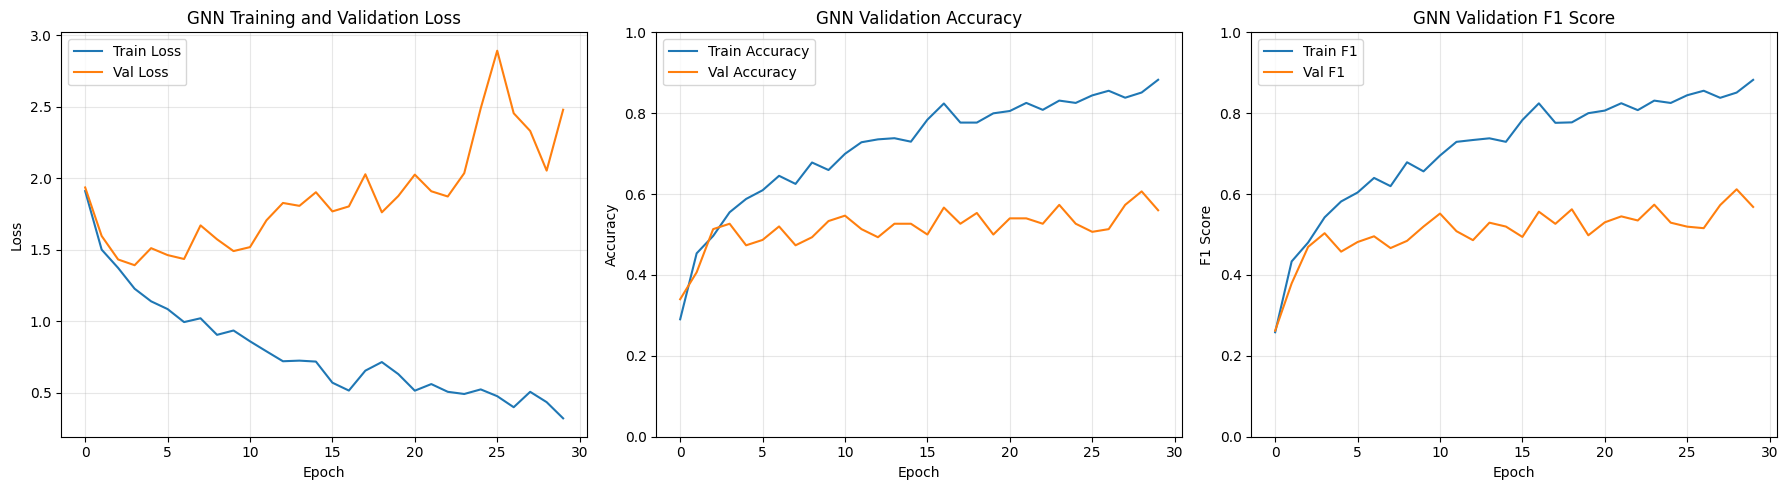

GNN training curves saved


In [ ]:
# GNN Training Curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(gnn_history['train_loss'], label='Train Loss')
axes[0].plot(gnn_history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('GNN Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(gnn_history['train_acc'], label='Train Accuracy')
axes[1].plot(gnn_history['val_acc'], label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('GNN Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1])

axes[2].plot(gnn_history['train_f1'], label='Train F1')
axes[2].plot(gnn_history['val_f1'], label='Val F1')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].set_title('GNN Validation F1 Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim([0, 1])

plt.tight_layout()
plt.savefig(f'{plots_dir}/task2_gnn_training_curves.png', dpi=150)
plt.show()
print("GNN training curves saved")

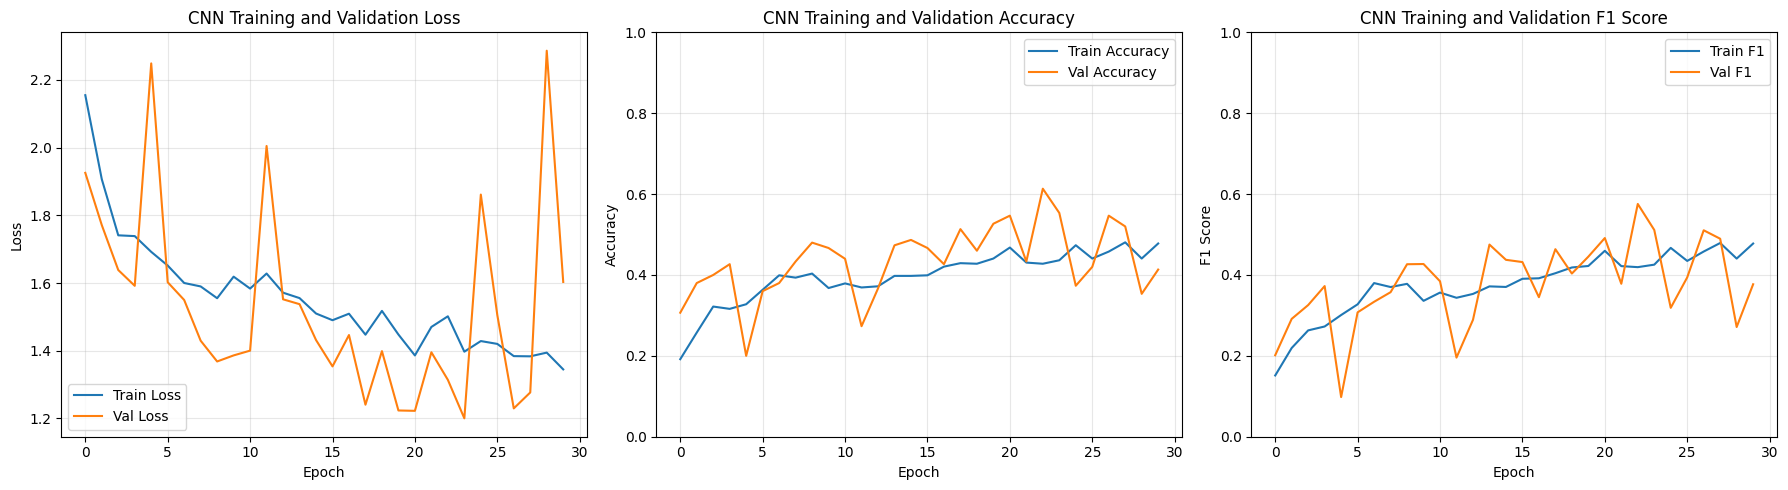

CNN training curves saved


In [ ]:
# CNN Training Curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(cnn_history['train_loss'], label='Train Loss')
axes[0].plot(cnn_history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('CNN Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(cnn_history['train_acc'], label='Train Accuracy')
axes[1].plot(cnn_history['val_acc'], label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('CNN Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1])

axes[2].plot(cnn_history['train_f1'], label='Train F1')
axes[2].plot(cnn_history['val_f1'], label='Val F1')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].set_title('CNN Training and Validation F1 Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim([0, 1])

plt.tight_layout()
plt.savefig(
    f'{plots_dir}/task2_cnn_training_curves.png',
    dpi=150
)
plt.show()

print("CNN training curves saved")

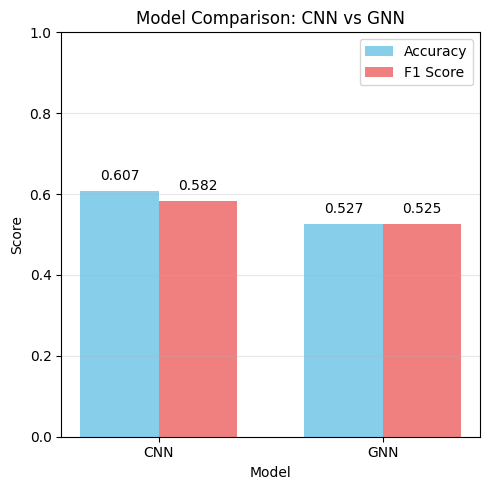

Model comparison saved


In [ ]:
# Model Comparison Bar Chart
fig, ax = plt.subplots(figsize=(5, 5))

models = ['CNN', 'GNN']
accuracies = [cnn_test_acc, gnn_test_acc]
f1_scores = [cnn_test_f1, gnn_test_f1]

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='skyblue')
bars2 = ax.bar(x + width/2, f1_scores, width, label='F1 Score', color='lightcoral')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison: CNN vs GNN')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1])

for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height:.3f}', ha='center', va='bottom', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(f'{plots_dir}/task2_model_comparison.png', dpi=150)
plt.show()
print("Model comparison saved")

In [ ]:
# Save GNN model
model_path = f'{PROJECT_ROOT}/src/task2_gnn_classifier'
torch.save(gnn_model.state_dict(), f'{model_path}.pt')
print(f"GNN model saved to {model_path}.pt")

# Save CNN model
cnn_path = f'{PROJECT_ROOT}/src/task2_cnn_baseline'
torch.save(cnn_model.state_dict(), f'{cnn_path}.pt')
print(f"CNN model saved to {cnn_path}.pt")

# Save metrics
metrics = {
    'task': 'Task 2: GNN on Music Structure Graphs',
    'gnn': {
        'model': 'GraphSAGE',
        'test_accuracy': float(gnn_test_acc),
        'test_f1_weighted': float(gnn_test_f1)
    },
    'cnn': {
        'model': 'SimpleCNN (Mel-Spectrogram)',
        'test_accuracy': float(cnn_test_acc),
        'test_f1_weighted': float(cnn_test_f1)
    },
    'comparison': {
        'accuracy_improvement': float(gnn_test_acc - cnn_test_acc),
        'f1_improvement': float(gnn_test_f1 - cnn_test_f1),
        'accuracy_improvement_percentage': float(((gnn_test_acc - cnn_test_acc) / cnn_test_acc) * 100) if cnn_test_acc > 0 else 0,
        'f1_improvement_percentage': float(((gnn_test_f1 - cnn_test_f1) / cnn_test_f1) * 100) if cnn_test_f1 > 0 else 0
    },
    'graph_stats': {
        'avg_nodes': float(np.mean([g.num_nodes for g in gtzan_dataset.graphs])),
        'avg_edges': float(np.mean([g_info['num_edges'] for g_info in gtzan_dataset.graph_infos])),
        'num_graphs': len(gtzan_dataset.graphs),
        'avg_node_features': gtzan_dataset.graphs[0].x.shape[1] if len(gtzan_dataset.graphs) > 0 else 0
    },
    'training_params': {
        'epochs': EPOCHS,
        'learning_rate': LEARNING_RATE,
        'batch_size': BATCH_SIZE,
        'gnn_hidden': GNN_HIDDEN,
        'gnn_layers': GNN_LAYERS,
        'dropout': DROPOUT
    }
}

GNN model saved to /content/CSE425_project/src/task2_gnn_classifier.pt
CNN model saved to /content/CSE425_project/src/task2_cnn_baseline.pt


In [ ]:
# Summary Statistics
print(f"\nResults Summary:")
print(f"   {'Model':15s} | {'Accuracy':>10s} | {'F1 Score':>10s}")
print(f"   {'-'*15} | {'-'*10} | {'-'*10}")
print(f"   {'CNN (Baseline)':15s} | {cnn_test_acc:>10.4f} | {cnn_test_f1:>10.4f}")
print(f"   {'GNN (GraphSAGE)':15s} | {gnn_test_acc:>10.4f} | {gnn_test_f1:>10.4f}")
print(f"   {'Improvement':15s} | {gnn_test_acc - cnn_test_acc:>+10.4f} | {gnn_test_f1 - cnn_test_f1:>+10.4f}")

print("\nGenerated Visualizations:")
print(f"   GNN Training Curves: {plots_dir}/task2_gnn_training_curves.png")
print(f"   CNN Training Curves: {plots_dir}/task2_cnn_training_curves.png")
print(f"   Model Comparison: {plots_dir}/task2_model_comparison.png")


Results Summary:
   Model           |   Accuracy |   F1 Score
   --------------- | ---------- | ----------
   CNN (Baseline)  |     0.6067 |     0.5818
   GNN (GraphSAGE) |     0.5267 |     0.5251
   Improvement     |    -0.0800 |    -0.0567

Generated Visualizations:
   GNN Training Curves: /content/CSE425_project/results/plots/task2_gnn_training_curves.png
   CNN Training Curves: /content/CSE425_project/results/plots/task2_cnn_training_curves.png
   Model Comparison: /content/CSE425_project/results/plots/task2_model_comparison.png
